<a href="https://www.kaggle.com/code/janmartins/dv-netflix-movies-and-tv-shows?scriptVersionId=224821493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Importando as bibliotecas que vamos utilizar e o caminho para os dados

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/netflix-movies-and-tv-shows/netflix_titles.csv


In [2]:
path = '/kaggle/input/netflix-movies-and-tv-shows/netflix_titles.csv'
df_path = pd.read_csv(path)
df_path.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df_path.shape

(8807, 12)

In [4]:
df_path.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Como temos muitos valores *nulos* vamos analisar a tabela evitando de usar essas colunas. Vamos olhar para a distribuição de filmes e series produzidas

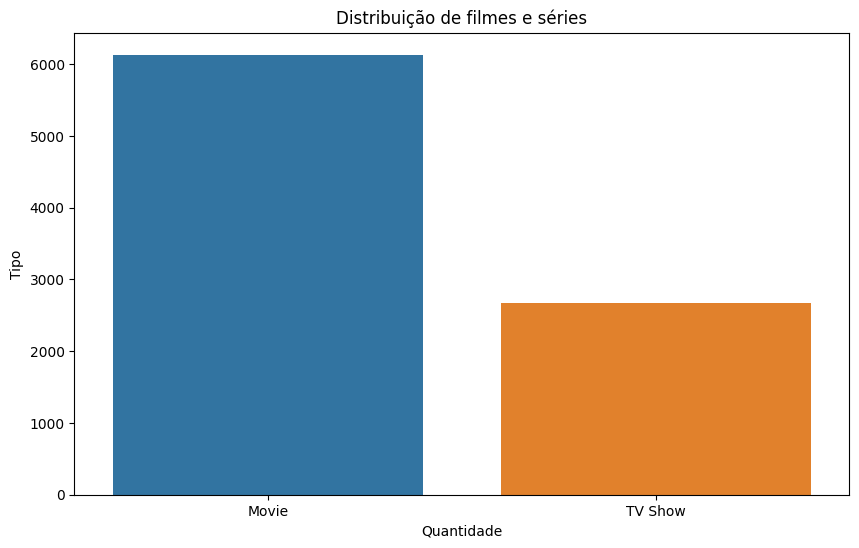

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_path, x='type')
plt.title('Distribuição de filmes e séries')
plt.xlabel('Quantidade')
plt.ylabel('Tipo')
plt.show()

In [6]:
qtd = df_path['type'].value_counts()
qtd

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

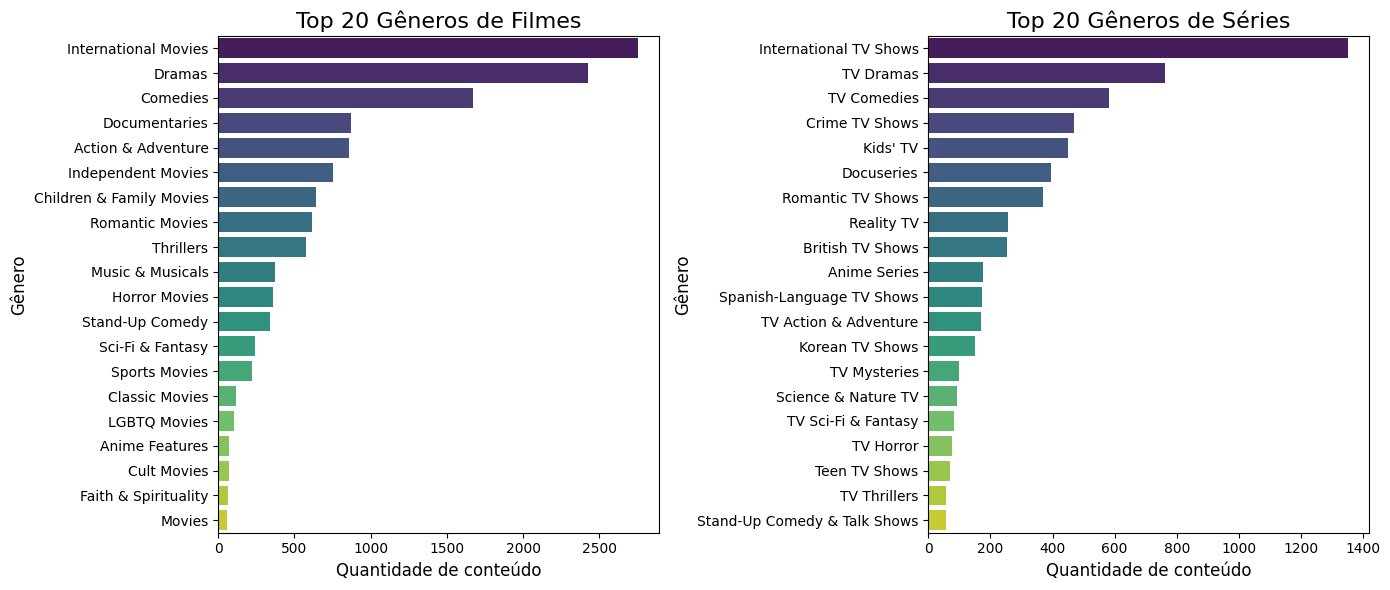

In [7]:
df_movies = df_path[df_path['type'] == 'Movie']
df_series = df_path[df_path['type'] == 'TV Show']

# Extraindo e contando os gêneros para filmes
genres_movies = df_movies['listed_in'].str.split(', ').explode()
top_genres_movies = genres_movies.value_counts().head(20)

# Extraindo e contando os gêneros para séries
genres_series = df_series['listed_in'].str.split(', ').explode()
top_genres_series = genres_series.value_counts().head(20)

# Plotando gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico para filmes
sns.barplot(x=top_genres_movies.values, y=top_genres_movies.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 Gêneros de Filmes', fontsize=16)
axes[0].set_xlabel('Quantidade de conteúdo', fontsize=12)
axes[0].set_ylabel('Gênero', fontsize=12)

# Gráfico para séries
sns.barplot(x=top_genres_series.values, y=top_genres_series.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 20 Gêneros de Séries', fontsize=16)
axes[1].set_xlabel('Quantidade de conteúdo', fontsize=12)
axes[1].set_ylabel('Gênero', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
# Vamos verificar quantos anos temos no gráfico que será gerado posteriormente.

print(sorted(df_path['release_year'].unique()))

[1925, 1942, 1943, 1944, 1945, 1946, 1947, 1954, 1955, 1956, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]


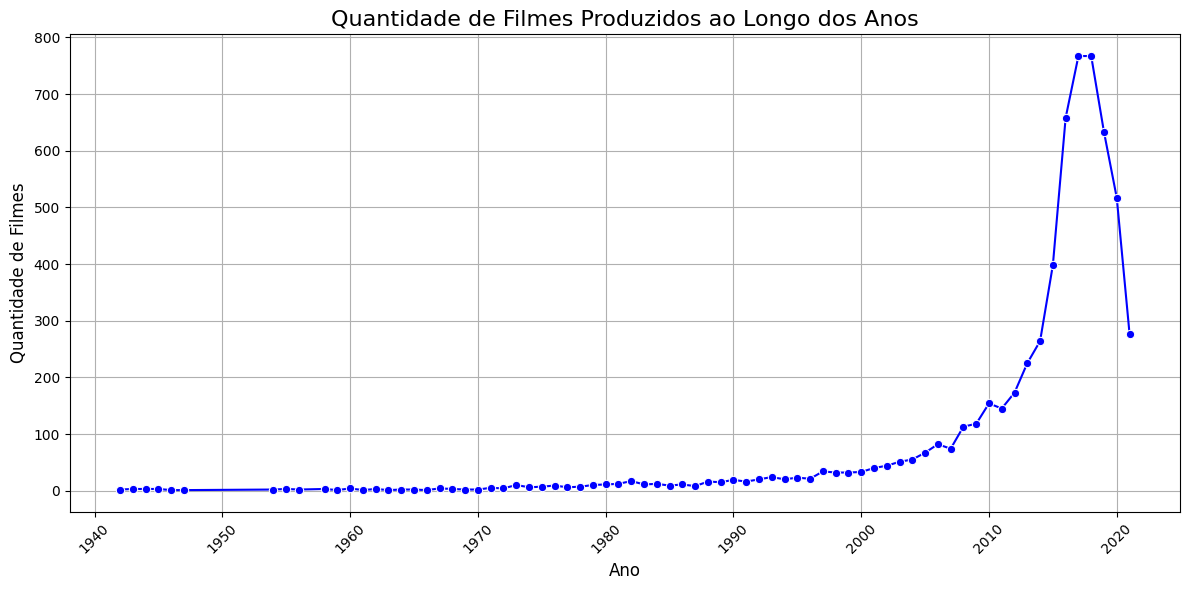

In [9]:
movies_per_year = df_movies['release_year'].value_counts().sort_index()

# Plotando o gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o', color='b')

#contabilizo  mesmo que outros valores na linha sejam NaN
series_per_year = df_series['release_year'].value_counts(dropna=False).sort_index()

# Personalizando o gráfico
plt.title('Quantidade de Filmes Produzidos ao Longo dos Anos', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Filmes', fontsize=12)
plt.xticks(rotation=45)  # Rotaciona os anos para melhor visualização
plt.grid(True)

plt.tight_layout()
plt.show()

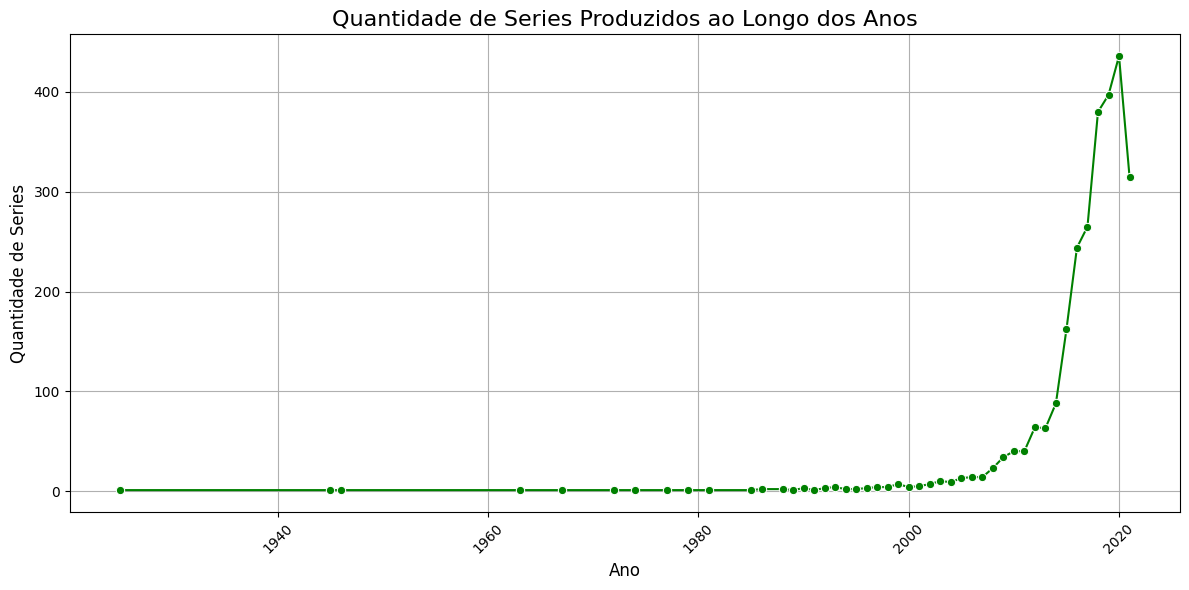

In [10]:
# Substituir valores inf por NaN
df_series.replace([np.inf, -np.inf], np.nan, inplace=True)

# Contabilizando as séries por ano, incluindo NaN
series_per_year = df_series['release_year'].value_counts(dropna=False).sort_index()

# Plotando o gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(x=series_per_year.index, y=series_per_year.values, marker='o', color='g')

# Personalizando o gráfico
plt.title('Quantidade de Series Produzidos ao Longo dos Anos', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Series', fontsize=12)
plt.xticks(rotation=45)  # Rotaciona os anos para melhor visualização
plt.grid(True)

plt.tight_layout()
plt.show()